In [ ]:
install.packages("e1071")
install.packages("cluster")
install.packages("factoextra")

library(e1071)
library(cluster)
library(factoextra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘plyr’, ‘abind’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘reshape2’, ‘ggrepel’


Warning message in install.packages("factoextra"):
“installation of package ‘quantreg’ had non-zero exit status”
Warning message in install.packages("factoextra"):
“ins

ERROR: Error in library(factoextra): there is no package called ‘factoextra’


In [ ]:
data <- read.csv("/content/Mall_Customers.csv")

head(data)

,CustomerID,Gender,Age,Annual.Income..k..,Spending.Score..1.100.
,<int>,<chr>,<int>,<int>,<int>
1,1,Male,19,15,39
2,2,Male,21,15,81
3,3,Female,20,16,6
4,4,Female,23,16,77
5,5,Female,31,17,40
6,6,Female,22,17,76


In [ ]:
# column wise missing values
x <- colSums(is.na(data))
x<-as.data.frame(x)
x
# Handle missing values
data<- na.omit(data)

,x
,<dbl>
CustomerID,0
Gender,0
Age,0
Annual.Income..k..,0
Spending.Score..1.100.,0


In [ ]:
data_for_clustering <- data[, c("Age", "Annual.Income..k..", "Spending.Score..1.100.")]


In [ ]:
set.seed(123)
n_cluster <- 5
m <- 2
result <- cmeans(data_for_clustering, centers = n_cluster, m = m)

# Fuzzy Membership Matrix
fuzzy_membership_matrix <- result$membership

# Cluster Centers
initial_centers <- result$centers
final_centers <- t(result$centers)


In [ ]:
cluster_membership <- as.data.frame(result$membership)
data_with_clusters <- cbind(data, cluster_membership)
head(data_with_clusters)


,CustomerID,Gender,Age,Annual.Income..k..,Spending.Score..1.100.,1,2,3,4,5
,<int>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,Male,19,15,39,0.37959181,0.17476309,0.2993177,0.07695700,0.06937042
2,2,Male,21,15,81,0.04963438,0.06026131,0.8238920,0.02238315,0.04382915
3,3,Female,20,16,6,0.54523117,0.15061179,0.1278583,0.11489288,0.06140591
4,4,Female,23,16,77,0.04225150,0.05057300,0.8560191,0.01779999,0.03335641
5,5,Female,31,17,40,0.47486580,0.17362395,0.2356519,0.06173411,0.05412422
6,6,Female,22,17,76,0.03856008,0.04628816,0.8685381,0.01624770,0.03036598


Clustering Gap statistic ["clusGap"] from call:
clusGap(x = data_for_clustering, FUNcluster = kmeans, K.max = 10, B = 50, nstart = 25)
B=50 simulated reference sets, k = 1..10; spaceH0="scaledPCA"
 --> Number of clusters (method 'firstSEmax', SE.factor=1): 1
          logW   E.logW       gap     SE.sim
 [1,] 7.829990 8.265710 0.4357194 0.01843194
 [2,] 7.625794 8.026844 0.4010507 0.02122827
 [3,] 7.417921 7.831518 0.4135978 0.02010003
 [4,] 7.256540 7.682076 0.4255360 0.02095295
 [5,] 7.104745 7.599099 0.4943545 0.01882403
 [6,] 6.965334 7.528066 0.5627315 0.02119889
 [7,] 6.903828 7.466770 0.5629417 0.02171223
 [8,] 6.847482 7.412180 0.5646979 0.02163216
 [9,] 6.804519 7.364572 0.5600536 0.02070945
[10,] 6.747791 7.320724 0.5729331 0.02025223


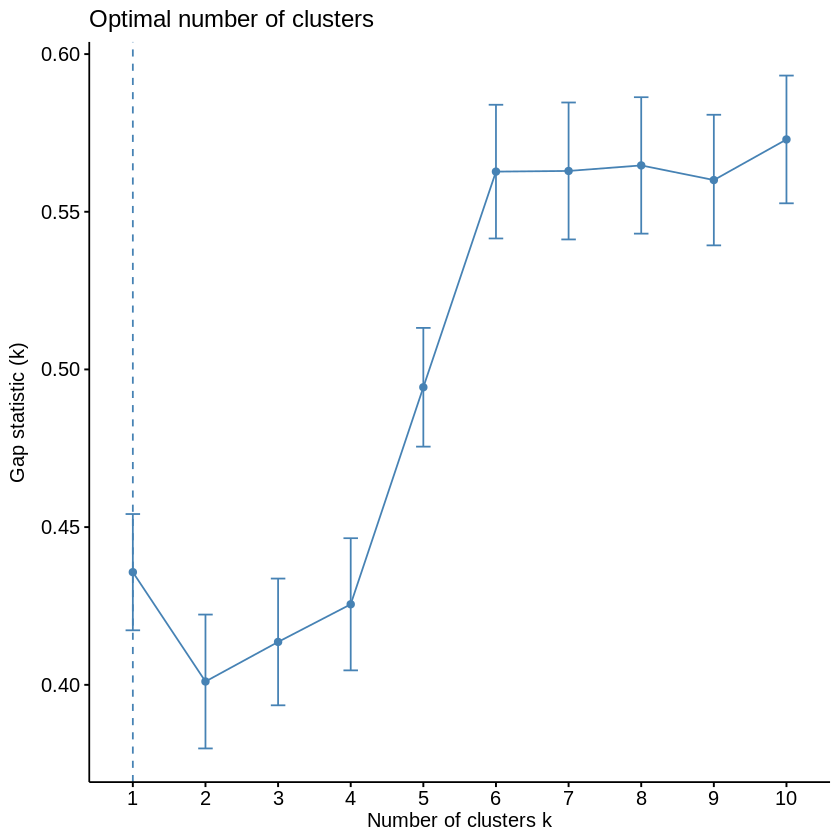

In [ ]:
library(cluster)

# Compute Gap Statistic using clusGap
gap_stat <- clusGap(data_for_clustering, FUN = kmeans, nstart = 25,
                    K.max = 10, B = 50)

# Print summary
print(gap_stat)

# Visualize Gap Statistic
fviz_gap_stat(gap_stat)


In [ ]:
# Install and load required package
install.packages("clusterSim")
library(clusterSim)

# Perform k-means clustering for evaluation
set.seed(123)
km_res <- kmeans(data_for_clustering, centers = 5, nstart = 25)

# Calculate Davies-Bouldin Index
db_index <- index.DB(data_for_clustering, km_res$cluster, centrotypes = "centroids")

# Print Davies-Bouldin Index
print(db_index$DB)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘pixmap’, ‘sp’, ‘RcppArmadillo’, ‘ade4’


Loading required package: MASS



[1] 0.884653


In [ ]:
# Calculate Calinski-Harabasz Index (also known as Variance Ratio Criterion)
ch_index <- index.G1(data_for_clustering, km_res$cluster)

# Print Calinski-Harabasz Index
print(ch_index)


[1] 151.0439


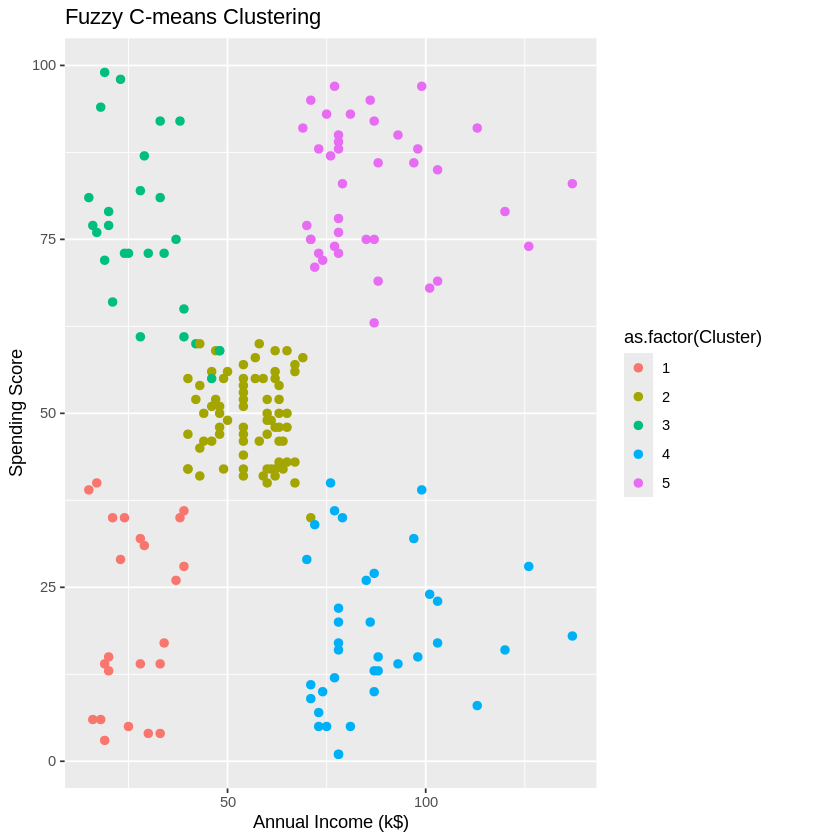

In [ ]:
data_with_clusters$Cluster <- apply(result$membership, 1, which.max)

ggplot(data_with_clusters, aes(x = Annual.Income..k.., y = Spending.Score..1.100., color = as.factor(Cluster))) +
  geom_point(size = 2) +
  labs(title = "Fuzzy C-means Clustering", x = "Annual Income (k$)", y = "Spending Score")


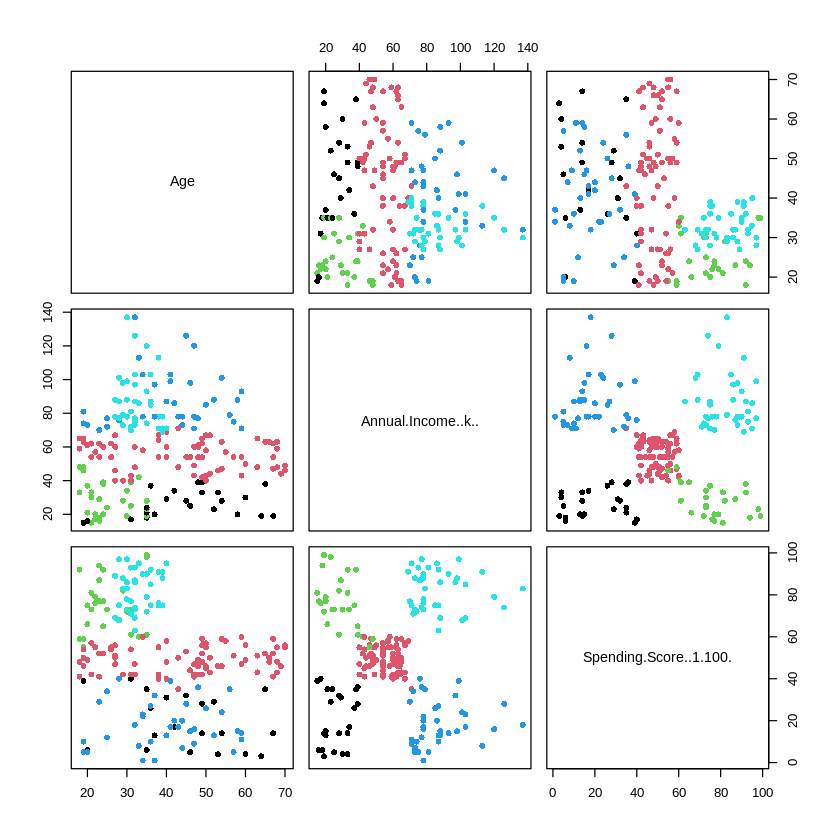

In [ ]:
pairs(data_for_clustering, pch = 16, col = as.numeric(result$cluster))


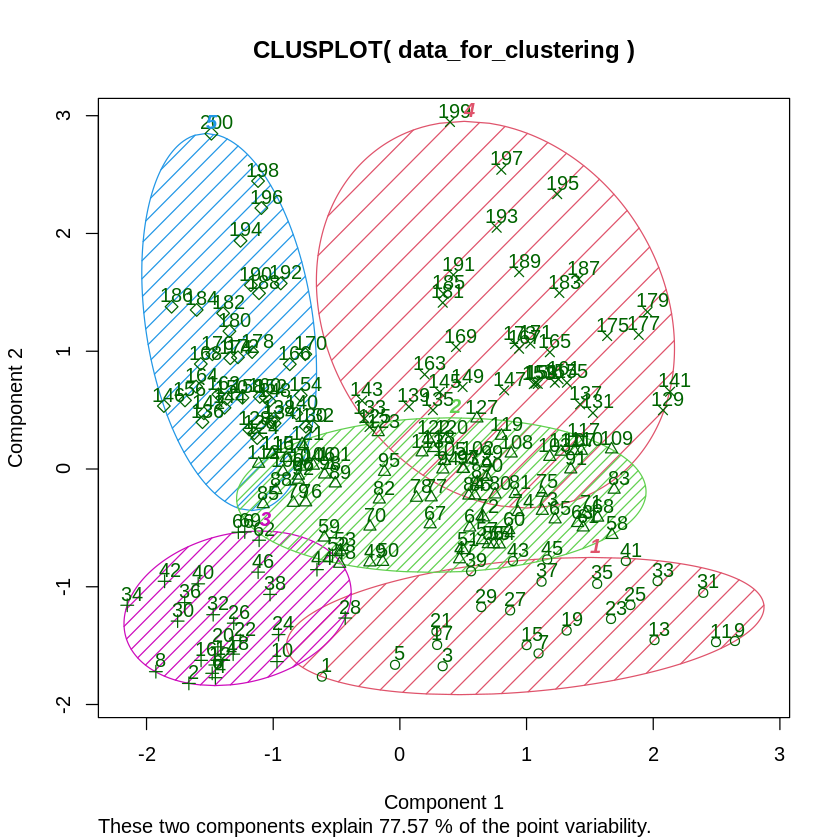

In [ ]:
clusplot(data_for_clustering, result$cluster, color = TRUE, shade = TRUE, labels = 2, lines = 0)
